# Método de Euler para ecuaciones diferenciales ordinarias

El **método de Euler** es un procedimiento numérico para aproximar la solución de problemas de valor inicial asociados a ecuaciones diferenciales ordinarias.

Este notebook presenta el fundamento del método, su implementación en Python y diferentes aplicaciones: una ecuación diferencial de primer orden, un modelo de propagación, un sistema presa-depredador y un sistema dinámico de sentimientos.

### Objetivos

- Comprender el funcionamiento del método de Euler.
- Implementar el método para problemas de valor inicial.
- Aplicar Euler tanto a ecuaciones escalares como a sistemas de ecuaciones diferenciales.
- Interpretar gráficamente el comportamiento de las soluciones aproximadas.
- Analizar cómo los parámetros de un modelo pueden modificar su dinámica.

**Tecnologías:** Python · NumPy · Matplotlib

## 1. Fundamento del método

Considere el problema de valor inicial:

$$
y'(t)=f(t,y), \qquad y(a)=\alpha
$$

El intervalo $[a,b]$ se divide en pasos de tamaño $h$. A partir del valor inicial, el método de Euler aproxima la solución mediante:

$$
w_0=\alpha
$$

$$
w_{i+1}=w_i+h\,f(t_i,w_i),
\qquad i=0,1,\ldots,N-1
$$

donde:

- $t_i$ es el punto actual del intervalo;
- $w_i$ es la aproximación numérica de $y(t_i)$;
- $f(t_i,w_i)$ representa la pendiente de la solución en el punto actual;
- $h$ es el tamaño del paso.

Geométricamente, Euler avanza desde cada punto utilizando la pendiente de la recta tangente. Por esta razón, un paso más pequeño suele mejorar la aproximación, aunque también aumenta el número de iteraciones.

Para una función suficientemente regular, el método de Euler es de **primer orden**: su error global es del orden de $O(h)$.

### Euler para sistemas

El mismo procedimiento puede aplicarse a sistemas de ecuaciones diferenciales. Si:

$$
\mathbf{y}'(t)=\mathbf{f}(t,\mathbf{y}),
$$

entonces:

$$
\mathbf{w}_{i+1}
=
\mathbf{w}_i+h\,\mathbf{f}(t_i,\mathbf{w}_i).
$$

En este caso, $w_i$ y $f(t_i,w_i)$ son vectores. Esta formulación permite estudiar modelos como los sistemas presa-depredador.

## 2. Implementación

La función recibe la ecuación diferencial, los extremos del intervalo, el tamaño del paso y la condición inicial. Luego genera las aproximaciones de manera iterativa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def Euler(Ecuacion, a, b, Espacio, co):
    n=int((b-a)/Espacio)
    w=[co]
    t=np.linspace(a,b,n+1)
    for i in range(n):
        w.append(w[i]+Espacio*Ecuacion(t[i], w[i]))
    return t, w

## 3. Aplicación 1 — Problema de valor inicial

Se desea aproximar la solución de:

$$
y'=te^{3t}-2y
$$

en el intervalo:

$$
0\leq t\leq1
$$

con condición inicial:

$$
y(0)=0
$$

y tamaño de paso:

$$
h=0.25.
$$

El problema permite observar directamente cómo Euler construye la solución a partir de la pendiente evaluada en cada punto.

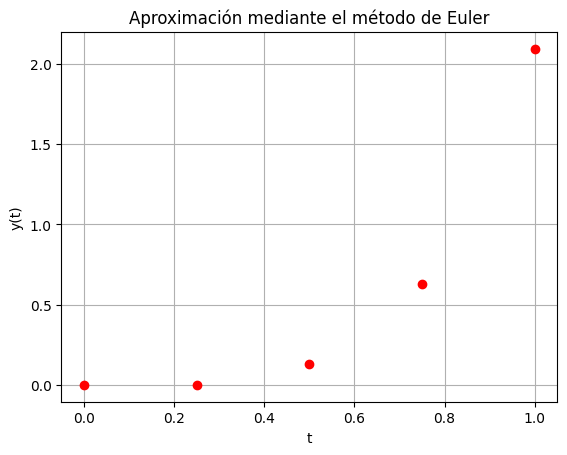

t = 0.00  ->  y ≈ 0.000000
t = 0.25  ->  y ≈ 0.000000
t = 0.50  ->  y ≈ 0.132313
t = 0.75  ->  y ≈ 0.626367
t = 1.00  ->  y ≈ 2.092134


In [2]:
Ecuacion=lambda t,y: t*np.exp(3*t)-2*y

t, w = Euler(Ecuacion, 0, 1, 0.25, 0)

plt.plot(t, w, 'or')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Aproximación mediante el método de Euler')
plt.grid(True)
plt.show()

for ti, wi in zip(t, w):
    print(f"t = {ti:.2f}  ->  y ≈ {wi:.6f}")

### Interpretación

Partiendo de $y(0)=0$, el método utiliza la pendiente calculada en cada punto para generar la siguiente aproximación.

Con $h=0.25$ se obtienen cinco valores desde $t=0$ hasta $t=1$. La última aproximación es:

$$
y(1)\approx2.0921.
$$

Este ejemplo muestra el proceso básico de Euler antes de aplicarlo a modelos más complejos.

## 4. Aplicación 2 — Propagación de un virus en una explotación ganadera

En una explotación de **1000 animales** se detecta inicialmente un animal contagiado. Se supone que la rapidez de propagación es proporcional al producto entre el número de animales contagiados y el tiempo transcurrido.

El modelo está dado por:

$$
\frac{dy}{dt}=kyt
$$

con:

$$
k=0.28782,
\qquad
y(0)=1.
$$

El objetivo es estimar el instante en el que el modelo alcanza los $1000$ animales contagiados.

Todos los animales se contagian aproximadamente en t ≈ 6.93


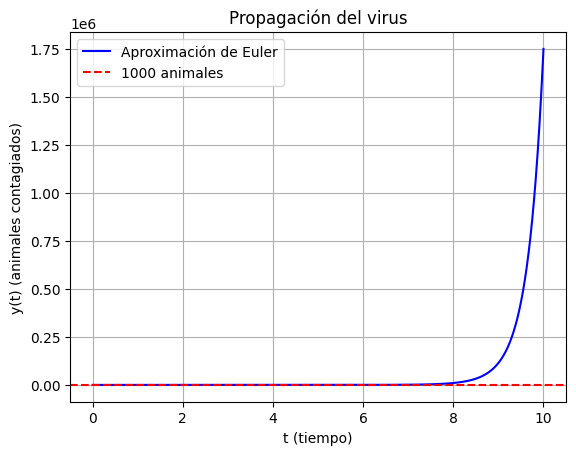

In [3]:
# Constante de proporción
k = 0.28782

# Ecuación diferencial: dy/dt = k * y * t
f = lambda t, y: k * y * t

# Condición inicial
c0 = 1

# Intervalo y tamaño del paso
a, b, Espacio = 0, 10, 0.001

t, w = Euler(f, a, b, Espacio, c0)

# Encontrar el momento en que y(t) alcanza 1000
for i in range(len(w)):
    if w[i] >= 1000:
        print(f"Todos los animales se contagian aproximadamente en t ≈ {t[i]:.2f}")
        break

# Graficar resultados
plt.plot(t, w, 'b-', label='Aproximación de Euler')
plt.axhline(1000, color='r', linestyle='--', label='1000 animales')
plt.xlabel('t (tiempo)')
plt.ylabel('y(t) (animales contagiados)')
plt.title('Propagación del virus')
plt.legend()
plt.grid(True)
plt.show()

### Interpretación

Con un tamaño de paso de $h=0.001$, el modelo alcanza aproximadamente los $1000$ animales en:

$$
t\approx6.93.
$$

La solución presenta un crecimiento cada vez más rápido porque la tasa de cambio depende tanto del número de animales ya contagiados como del tiempo.

El resultado debe interpretarse dentro del modelo matemático propuesto: una vez alcanzada la población total de la explotación, el modelo deja de tener significado físico si continúa aumentando.

## 5. Aplicación 3 — Modelo presa-depredador de Lotka–Volterra

Se estudia la interacción entre dos especies:

- $x_1(t)$: población de presas;
- $x_2(t)$: población de depredadores.

El sistema está dado por:

$$
x'_1(t)=k_1x_1(t)-k_2x_1(t)x_2(t)
$$

$$
x'_2(t)=k_3x_1(t)x_2(t)-k_4x_2(t).
$$

Los términos representan:

- $k_1x_1$: crecimiento natural de las presas;
- $k_2x_1x_2$: disminución de presas por interacción con depredadores;
- $k_3x_1x_2$: crecimiento de depredadores asociado a la disponibilidad de presas;
- $k_4x_2$: mortalidad natural de los depredadores.

Se utilizan las condiciones iniciales:

$$
x_1(0)=1000,
\qquad
x_2(0)=500
$$

y los parámetros:

$$
k_1=3,\quad
k_2=0.002,\quad
k_3=0.0006,\quad
k_4=0.5.
$$

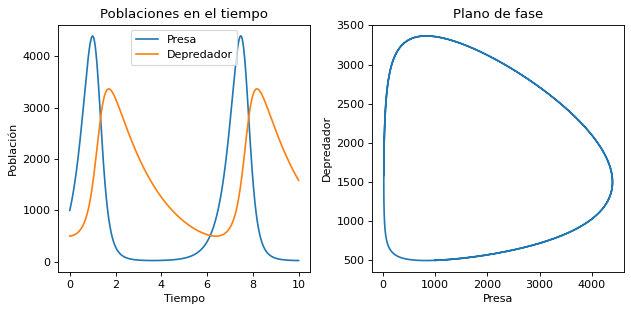

In [4]:
def competencia(t, especies):
    presas= especies[0]
    depredadores=especies[1]
    k1=3
    k2=0.002
    k3=0.0006
    k4=0.5
    eq_presa=k1*presas-k2*presas*depredadores
    eq_depre=k3*presas*depredadores-k4*depredadores
    return np.array([eq_presa, eq_depre])

tiempo, especie= Euler(competencia, 0, 10, 0.0001,[1000, 500])

presa=np.array(especie)[:,0]
depre=np.array(especie)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, presa)
plt.plot(tiempo, depre)
plt.xlabel('Tiempo')
plt.ylabel('Población')
plt.legend(['Presa', 'Depredador'])
plt.title('Poblaciones en el tiempo')

plt.subplot(122)
plt.plot(presa, depre)
plt.xlabel('Presa')
plt.ylabel('Depredador')
plt.title('Plano de fase')

plt.tight_layout()
plt.show()

### Interpretación

Las dos poblaciones presentan un comportamiento oscilatorio relacionado.

Cuando la población de presas aumenta, existe mayor disponibilidad de alimento y posteriormente aumenta la población de depredadores. El crecimiento de los depredadores incrementa la presión sobre las presas, cuya población disminuye. Después, la reducción de presas limita el alimento disponible y también disminuye la población de depredadores.

La gráfica temporal muestra esta alternancia, mientras que el plano de fase permite observar la relación entre ambas poblaciones durante la evolución del sistema.

## 6. Variación de parámetros del modelo presa-depredador

Para analizar la sensibilidad del sistema se realizan dos simulaciones adicionales modificando las constantes de natalidad y mortalidad.

El objetivo no es buscar un único conjunto de parámetros, sino observar cómo diferentes tasas producen dinámicas poblacionales distintas.

### Simulación 1

Se utilizan:

$$
k_1=3,\quad
k_2=0.002,\quad
k_3=0.006,\quad
k_4=0.002.
$$

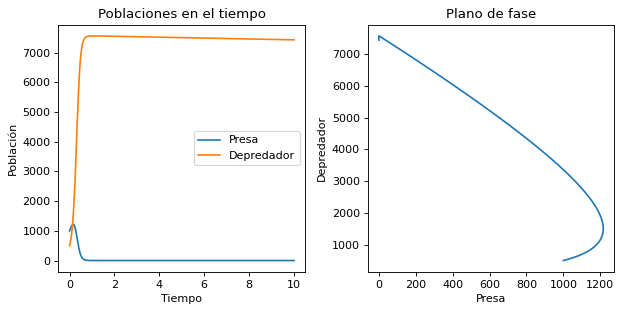

In [5]:
def competencia2(t, especies):
    presas= especies[0]
    depredadores=especies[1]
    k1=3
    k2=0.002 # Constante de mortalidad
    k3=0.006 # Constante de natalidad
    k4=0.002 # Constante de mortalidad
    eq_presa=k1*presas-k2*presas*depredadores
    eq_depre=k3*presas*depredadores-k4*depredadores
    return np.array([eq_presa, eq_depre])

tiempo, especie= Euler(competencia2, 0, 10, 0.0001,[1000, 500])

presa=np.array(especie)[:,0]
depre=np.array(especie)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, presa)
plt.plot(tiempo, depre)
plt.xlabel('Tiempo')
plt.ylabel('Población')
plt.legend(['Presa', 'Depredador'])
plt.title('Poblaciones en el tiempo')

plt.subplot(122)
plt.plot(presa, depre)
plt.xlabel('Presa')
plt.ylabel('Depredador')
plt.title('Plano de fase')

plt.tight_layout()
plt.show()

### Interpretación

En esta simulación aumenta considerablemente la constante asociada al crecimiento de los depredadores y disminuye su tasa de mortalidad.

Como consecuencia, la población de depredadores alcanza valores mucho mayores y la población de presas se reduce hasta valores prácticamente nulos dentro del intervalo estudiado. Esto muestra la fuerte dependencia del comportamiento del sistema respecto a sus parámetros.

### Simulación 2

Se utilizan:

$$
k_1=1.5,\quad
k_2=0.002,\quad
k_3=0.001,\quad
k_4=0.5.
$$

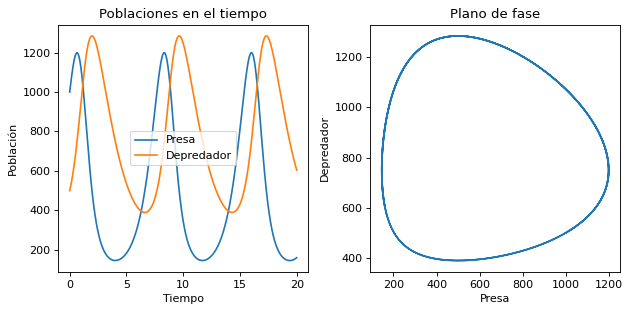

In [6]:
def competencia3(t, especies):
    presas= especies[0]
    depredadores=especies[1]
    k1=1.5
    k2=0.002 # Constante de mortalidad
    k3=0.001 # Constante de natalidad
    k4=0.5 # Constante de mortalidad
    eq_presa=k1*presas-k2*presas*depredadores
    eq_depre=k3*presas*depredadores-k4*depredadores
    return np.array([eq_presa, eq_depre])

tiempo, especie= Euler(competencia3, 0, 20, 0.0001,[1000, 500])

presa=np.array(especie)[:,0]
depre=np.array(especie)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, presa)
plt.plot(tiempo, depre)
plt.xlabel('Tiempo')
plt.ylabel('Población')
plt.legend(['Presa', 'Depredador'])
plt.title('Poblaciones en el tiempo')

plt.subplot(122)
plt.plot(presa, depre)
plt.xlabel('Presa')
plt.ylabel('Depredador')
plt.title('Plano de fase')

plt.tight_layout()
plt.show()

### Interpretación

Con este conjunto de parámetros las poblaciones continúan mostrando oscilaciones, pero con un rango diferente al del caso original.

La comparación entre las simulaciones evidencia que cambios en las tasas de crecimiento, interacción y mortalidad pueden alterar de manera importante la amplitud y evolución de las poblaciones.

## 7. Aplicación 4 — Sistema dinámico de sentimientos

Se considera un modelo donde:

- $x(t)$ representa el sentimiento de Denise hacia Craig;
- $y(t)$ representa el sentimiento de Craig hacia Denise.

El sistema es:

$$
x'=y+\sin(ct)
$$

$$
y'=-4x
$$

con condiciones iniciales:

$$
x(0)=0,\qquad y(0)=0.
$$

El término $\sin(ct)$ representa una influencia externa periódica asociada a las experiencias compartidas. Se estudian:

$$
c=0.5,\quad1.5,\quad2.2,\quad3.
$$

Al derivar la primera ecuación y utilizar la segunda se obtiene:

$$
x''+4x=c\cos(ct).
$$

Por tanto, la frecuencia natural del sistema es $2$. Esto permite analizar qué ocurre cuando $c$ se aproxima a ese valor y cuando lo supera.

### Caso $c=0.5$

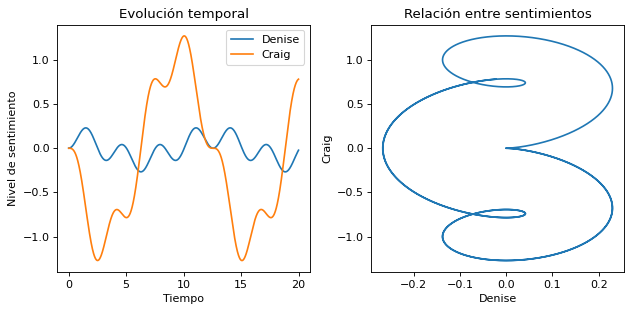

In [7]:
def competenciaRomance(tiempo, sentimientos):
    Denise=sentimientos[0]
    Craig=sentimientos[1]
    C=0.5
    eq_Denise= Craig + np.sin(C*tiempo)
    eq_Craig = -4*Denise
    return np.array([eq_Denise, eq_Craig])

tiempo, sentimientos= Euler(competenciaRomance, 0, 20, 0.0001,[0,0])

Denise=np.array(sentimientos)[:,0]
Craig=np.array(sentimientos)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, Denise)
plt.plot(tiempo, Craig)
plt.xlabel('Tiempo')
plt.ylabel('Nivel de sentimiento')
plt.legend(['Denise', 'Craig'])
plt.title('Evolución temporal')

plt.subplot(122)
plt.plot(Denise, Craig)
plt.xlabel('Denise')
plt.ylabel('Craig')
plt.title('Relación entre sentimientos')

plt.tight_layout()
plt.show()

### Caso $c=1.5$

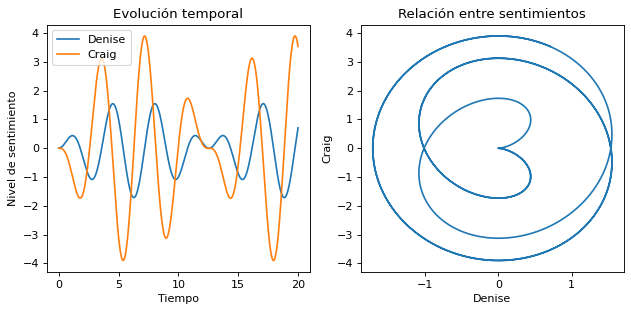

In [8]:
def competenciaRomance(tiempo, sentimientos):
    Denise=sentimientos[0]
    Craig=sentimientos[1]
    C=1.5
    eq_Denise= Craig + np.sin(C*tiempo)
    eq_Craig = -4*Denise
    return np.array([eq_Denise, eq_Craig])

tiempo, sentimientos= Euler(competenciaRomance, 0, 20, 0.0001,[0,0])

Denise=np.array(sentimientos)[:,0]
Craig=np.array(sentimientos)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, Denise)
plt.plot(tiempo, Craig)
plt.xlabel('Tiempo')
plt.ylabel('Nivel de sentimiento')
plt.legend(['Denise', 'Craig'])
plt.title('Evolución temporal')

plt.subplot(122)
plt.plot(Denise, Craig)
plt.xlabel('Denise')
plt.ylabel('Craig')
plt.title('Relación entre sentimientos')

plt.tight_layout()
plt.show()

### Caso $c=2.2$

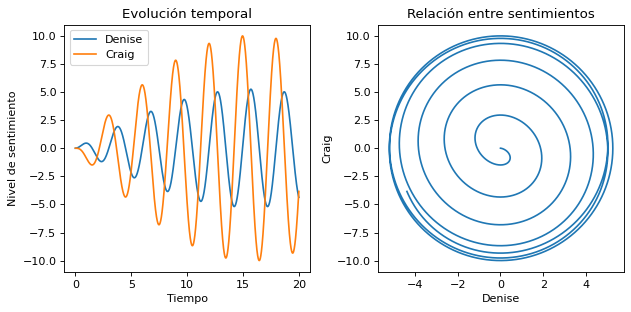

In [9]:
def competenciaRomance(tiempo, sentimientos):
    Denise=sentimientos[0]
    Craig=sentimientos[1]
    C=2.2
    eq_Denise= Craig + np.sin(C*tiempo)
    eq_Craig = -4*Denise
    return np.array([eq_Denise, eq_Craig])

tiempo, sentimientos= Euler(competenciaRomance, 0, 20, 0.0001,[0,0])

Denise=np.array(sentimientos)[:,0]
Craig=np.array(sentimientos)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, Denise)
plt.plot(tiempo, Craig)
plt.xlabel('Tiempo')
plt.ylabel('Nivel de sentimiento')
plt.legend(['Denise', 'Craig'])
plt.title('Evolución temporal')

plt.subplot(122)
plt.plot(Denise, Craig)
plt.xlabel('Denise')
plt.ylabel('Craig')
plt.title('Relación entre sentimientos')

plt.tight_layout()
plt.show()

### Caso $c=3$

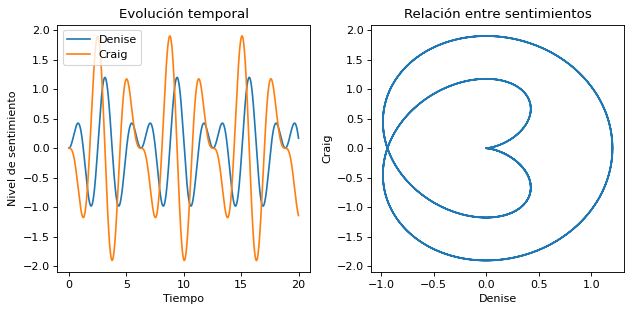

In [10]:
def competenciaRomance(tiempo, sentimientos):
    Denise=sentimientos[0]
    Craig=sentimientos[1]
    C=3
    eq_Denise= Craig + np.sin(C*tiempo)
    eq_Craig = -4*Denise
    return np.array([eq_Denise, eq_Craig])

tiempo, sentimientos= Euler(competenciaRomance, 0, 20, 0.0001,[0,0])

Denise=np.array(sentimientos)[:,0]
Craig=np.array(sentimientos)[:,1]

plt.figure(figsize=(8,4),dpi=80)

plt.subplot(121)
plt.plot(tiempo, Denise)
plt.plot(tiempo, Craig)
plt.xlabel('Tiempo')
plt.ylabel('Nivel de sentimiento')
plt.legend(['Denise', 'Craig'])
plt.title('Evolución temporal')

plt.subplot(122)
plt.plot(Denise, Craig)
plt.xlabel('Denise')
plt.ylabel('Craig')
plt.title('Relación entre sentimientos')

plt.tight_layout()
plt.show()

### Interpretación

La respuesta del sistema cambia de manera importante según el valor de $c$.

- Para $c=0.5$, la amplitud de las oscilaciones es relativamente pequeña.
- Para $c=1.5$, al acercarse a la frecuencia natural $2$, la respuesta aumenta.
- Para $c=2.2$, que se encuentra muy cerca de $2$, se observan las oscilaciones de mayor amplitud entre los casos analizados.
- Para $c=3$, al alejarse nuevamente de la frecuencia natural, la amplitud disminuye.

Esto es coherente con el comportamiento de un sistema forzado cuya frecuencia externa se aproxima a su frecuencia natural. En $c=2$ se produciría el caso resonante ideal del modelo.

## 8. Consideraciones numéricas

El método de Euler es sencillo y útil para comprender la construcción de soluciones aproximadas, pero su precisión depende del tamaño del paso.

En las aplicaciones con sistemas se utiliza un paso pequeño (`0.0001`) para representar con mayor detalle la evolución de las variables. Sin embargo, disminuir el paso también incrementa el costo computacional.

Además, Euler es un método explícito de primer orden, por lo que problemas más exigentes pueden requerir métodos de mayor precisión o mejores propiedades de estabilidad.

## 9. Conclusiones

A partir de las aplicaciones desarrolladas se puede concluir que:

- El método de Euler aproxima problemas de valor inicial utilizando la pendiente de la ecuación diferencial en cada paso.
- La misma implementación puede trabajar con valores escalares y con vectores, lo que permite resolver sistemas de ecuaciones diferenciales.
- El tamaño del paso influye directamente en la precisión y en el costo computacional.
- Los modelos diferenciales permiten representar fenómenos de crecimiento, propagación e interacción entre variables.
- En el modelo presa-depredador, los parámetros modifican de manera significativa la dinámica de ambas poblaciones.
- En el sistema de sentimientos, la respuesta aumenta cuando la frecuencia externa se aproxima a la frecuencia natural del sistema.
- Las gráficas temporales y los planos de fase son herramientas útiles para interpretar el comportamiento de sistemas dinámicos.